Лабораторна робота 1

ФБ-61мп Князян Кирило

датасет: https://www.kaggle.com/datasets/adityakadiwal/water-potability

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix

1 Завантажую датасет та проводжу аналіз, цілбовою змінною є potability - придатність води для пиття

In [46]:
df = pd.read_csv("water_potability.csv")

print("Назви колонок:", df.columns.tolist())
print("Розмір датасета:", df.shape)

target = "Potability"
features = [col for col in df.columns if col != target]

print("\nТипи даних:\n", df.dtypes)

print("\nРозподіл цільової змінної (Potability):")
print(df[target].value_counts(normalize=True))

Назви колонок: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']
Розмір датасета: (3276, 10)

Типи даних:
 ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Розподіл цільової змінної (Potability):
Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


2 У даних є пропуски. Видалення всіх рядків з пропусками призведе до значної втрати інформації, тому заповню їх медіанними значеннями. Категоріальних ознак немає, тому кодування не потрібне.

In [47]:
print("Пропущені значення до обробки:\n", df.isnull().sum())

for col in features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nПропущені значення після обробки:\n", df.isnull().sum())

Пропущені значення до обробки:
 ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Пропущені значення після обробки:
 ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


3 Будую теплову карту кореляцій для перевірки на мультиколінеарність, а також гістограми та boxplot-и для аналізу розподілу.

Короткий висновок з графіків:
Сильних лінійних кореляцій між ознаками немає. На boxplot-ах видно, що медіани та міжквартильні розмахи (IQR) для класів 0 та 1 майже ідентичні - класи сильно перекриваються. Це свідчить про те, що задача нелінійна, і прості лінійні класифікатори можуть працювати гірше.

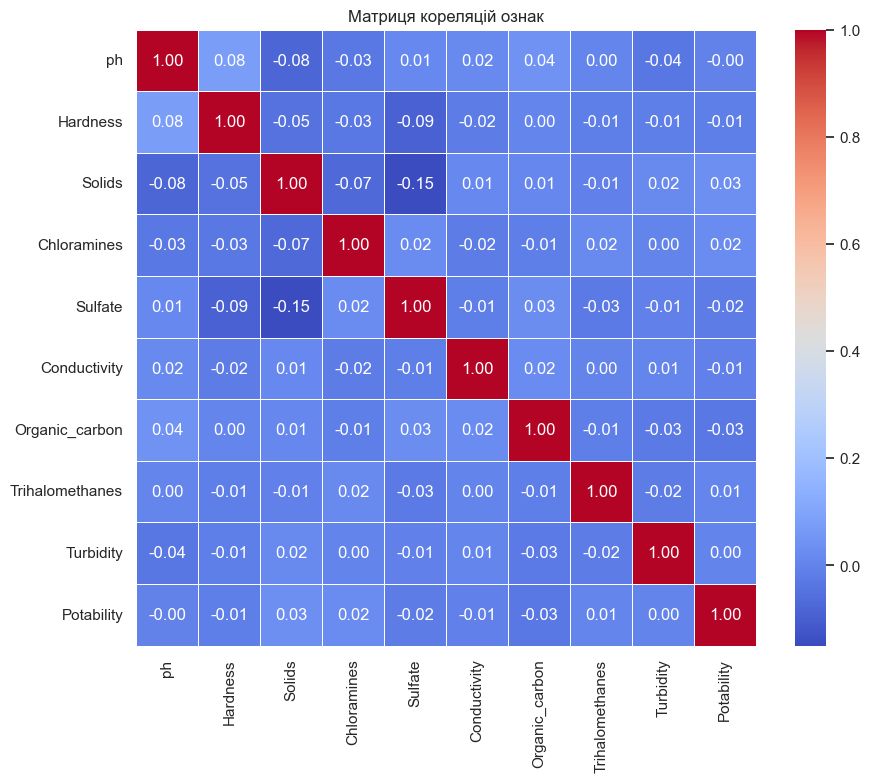

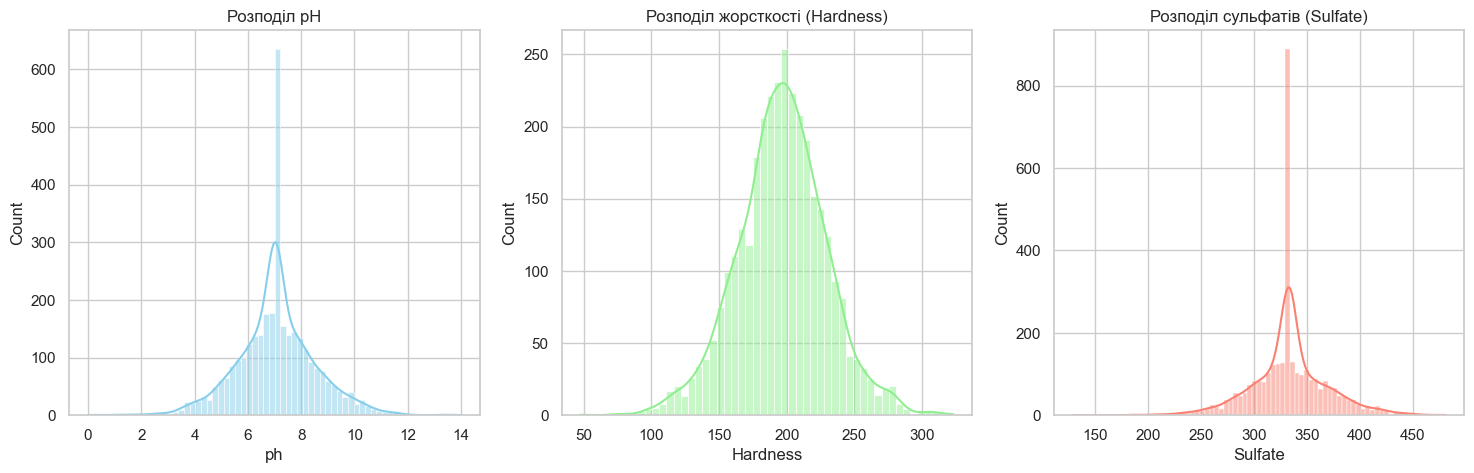

C:\Users\User\AppData\Local\Temp\ipykernel_16144\568565665.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y="ph", data=df, ax=axes[0], palette="Set2").set_title("pH vs Potability")
C:\Users\User\AppData\Local\Temp\ipykernel_16144\568565665.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y="Hardness", data=df, ax=axes[1], palette="Set2").set_title("Hardness vs Potability")
C:\Users\User\AppData\Local\Temp\ipykernel_16144\568565665.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y="Sulfate", data=d

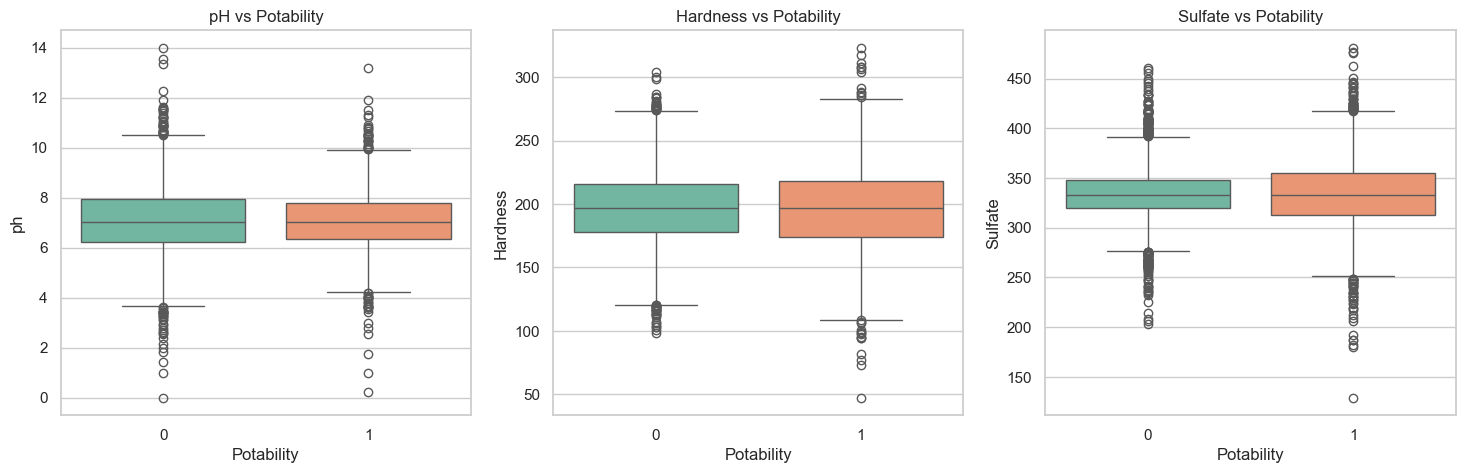

In [48]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Матриця кореляцій ознак")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["ph"], kde=True, ax=axes[0], color="skyblue").set_title("Розподіл pH")
sns.histplot(df["Hardness"], kde=True, ax=axes[1], color="lightgreen").set_title("Розподіл жорсткості (Hardness)")
sns.histplot(df["Sulfate"], kde=True, ax=axes[2], color="salmon").set_title("Розподіл сульфатів (Sulfate)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x=target, y="ph", data=df, ax=axes[0], palette="Set2").set_title("pH vs Potability")
sns.boxplot(x=target, y="Hardness", data=df, ax=axes[1], palette="Set2").set_title("Hardness vs Potability")
sns.boxplot(x=target, y="Sulfate", data=df, ax=axes[2], palette="Set2").set_title("Sulfate vs Potability")
plt.show()

4 Розділяю дані на навчальну та тестову вибірки та виконую стандартизацію даних.

In [49]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5-6 Навчаю 5 моделей: kNN, SVM, Decision Tree, Random Forest та AdaBoost.
Для kNN та SVM використовую GridSearchCV для автоматичного пошуку найкращих гіперпараметрів.

In [50]:
best_models = {}

knn_params = {"n_neighbors": [3, 5, 7, 9, 11, 15, 21]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring="accuracy")
knn_grid.fit(X_train_scaled, y_train)
best_models["kNN"] = knn_grid.best_estimator_
print(f"Найкращі параметри для kNN: {knn_grid.best_params_}")

svm_params = {"C": [0.1, 1, 10], "gamma": ["scale", "auto", 0.1, 1]}
svm_grid = GridSearchCV(SVC(), svm_params, cv=5, scoring="accuracy")
svm_grid.fit(X_train_scaled, y_train)
best_models["SVM"] = svm_grid.best_estimator_
print(f"Найкращі параметри для SVM: {svm_grid.best_params_}")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
best_models["Decision Tree"] = dt_model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
best_models["Random Forest"] = rf_model

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train_scaled, y_train)
best_models["AdaBoost"] = ada_model

Найкращі параметри для kNN: {'n_neighbors': 21}
Найкращі параметри для SVM: {'C': 1, 'gamma': 'scale'}


d:\python\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


7 Загальний висновок:

Вибір найкращої моделі залежить від цільової метрики. Найвищу загальну точність (accuracy = 0.67) показала модель SVM, оскільки вона дуже добре розпізнає масовий клас непридатної води (recall = 0.93). Проте, для ідентифікації саме питної води найкраще підходить Decision Tree: ця модель має найвищий F1-score (0.47) та набагато краще знаходить чисті зразки (recall = 0.45). Загальний рівень точності всіх моделей у 60-67% зумовлений виключно специфікою датасета: дисбалансом та сильним перекриттям ознак обох класів, що унеможливлює ідеальне математичне розділення.


Модель: kNN
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.91      0.75       400
           1       0.59      0.21      0.31       256

    accuracy                           0.63       656
   macro avg       0.62      0.56      0.53       656
weighted avg       0.62      0.63      0.58       656



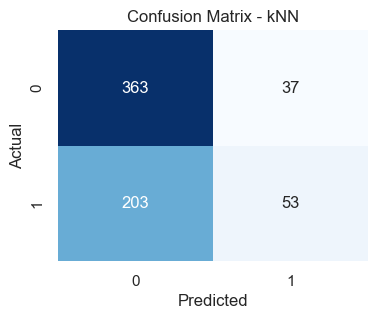


Модель: SVM
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656



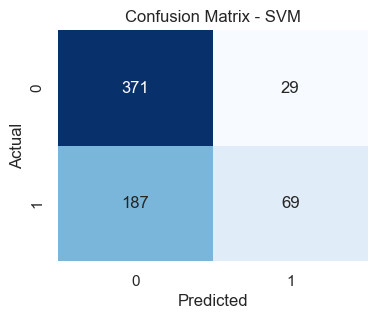


Модель: Decision Tree
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.69      0.67       400
           1       0.48      0.45      0.47       256

    accuracy                           0.60       656
   macro avg       0.57      0.57      0.57       656
weighted avg       0.59      0.60      0.59       656



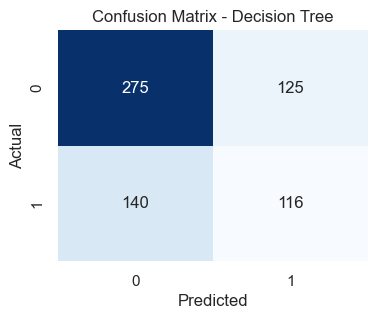


Модель: Random Forest
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.63      0.30      0.41       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.65      0.66      0.62       656



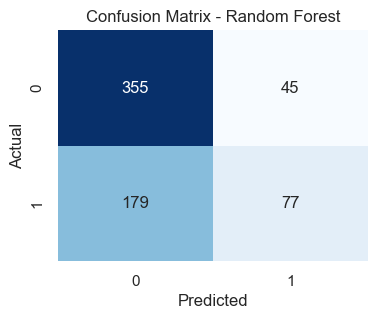


Модель: AdaBoost
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.85      0.72       400
           1       0.48      0.21      0.30       256

    accuracy                           0.60       656
   macro avg       0.56      0.53      0.51       656
weighted avg       0.57      0.60      0.56       656



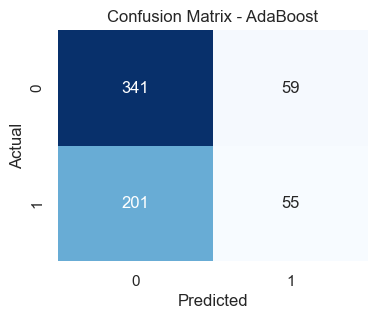

In [51]:
for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*40}")
    print(f"Модель: {name}")
    print(f"{'='*40}")
    
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()